# WSI Inference v4 — batch over all slides in a folder

Detects nuclei and classifies them by tissue type for every slide matching `WSI_DIR / WSI_GLOB`.  
Model: **ConvNeXt-v2 encoder + StarDist + multi-task classifier** (`StardistMultitaskNetV2`).

**Run cells top-to-bottom.  Only Cell 2 (Parameters) needs editing.**

| Cell | Purpose |
|------|---------|
| 1 | Imports |
| **2** | **Parameters ← edit here** |
| 3 | Load model weights |
| 4 | Colour helpers (colormap + QuPath RGB) |
| 5 | Open diagnostic slide + thumbnail |
| 6 | Single-tile diagnostic panel (sanity-check before batch) |
| **7** | **Batch inference** — all slides → `{stem}_classified.geojson` |
| 7b | Combined summary → `all_slides_summary.json` |
| 8 | Results bar chart (last slide) |

**Outputs written to `OUT_DIR`:**
- `{stem}_classified.geojson` — polygons + tissue class + QuPath colour
- `{stem}_summary.json` — parameters, timing, per-class counts
- `all_slides_summary.json` — aggregated stats across every slide


---
## 1 · Imports
*(run once; do not edit)*

In [1]:
import json
import time
import concurrent.futures
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm, ListedColormap
from tqdm import tqdm
import torch
import openslide
import yaml

# All inference helpers live in inference_utils — edit that file to change logic.
from inference_utils import *
from geometry import *

print("Imports OK")

Imports OK


---
## 2 · Parameters  ← edit here

**This is the only cell you need to change between experiments.**

Sections:
- **Paths** — slide folder, weights, config, output directory
- **Class palette** — display names and colours (must match checkpoint)
- **Class permutation** — only needed for pre-2025 alphabetical checkpoints
- **Slide / tile geometry** — level, tile size, overlap, valid margin
- **Detection thresholds** — probability threshold, NMS distance
- **Deduplication** — centroid NMS + polygon overlap (two-stage)
- **Hardware / speed** — device, fp16, batch size, workers
- **GeoJSON export** — indentation, coordinate precision, gzip
- **Diagnostic tile** — how to pick the sample tile in Cell 5–6

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────────
WSI_DIR      = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40")
WSI_GLOB     = "*.ndpi"
SLIDE_INDEX  = 1

_cands = sorted(WSI_DIR.glob(WSI_GLOB))
if not _cands:
    raise FileNotFoundError(f"No files matching {WSI_GLOB!r} under {WSI_DIR}")
SLIDE_PATH = _cands[int(SLIDE_INDEX) % len(_cands)]

# ── Checkpoints ──────────────────────────────────────────────────────────────
WEIGHTS_PATH = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_256_40k_48_slides\convnext_stardist_multitask_runs\run_gs40_gs55_v3_finetune\convnext_stardist_mt_gs40_gs55_v3_finetune\best.pt")
# WEIGHTS_PATH = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_256_40k_48_slides\convnext_stardist_multitask_runs\run_gs40_gs55_v3\convnext_stardist_mt_gs40_gs55_v3\best.pt")
# WEIGHTS_PATH = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_256_40k_48_slides\convnext_stardist_multitask_runs\run_gs40_gs55_v2\convnext_stardist_mt_gs40_gs55_v2_cls2L_skip128\best.pt")

CONFIG_PATH  = Path(r"C:\Users\Andre\cursor_projects\Convnext_stardist\shared_convnext_stardist_decoder\config_finetune_gs40_gs55.yaml")
OUT_DIR      = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\infer_gs40_gs55_v3_finetune")

# ── Class display palette ──────────────────────────────────────────────────────
LABELS_VIZ = [
    "bone",   "brain",  "eye",       "heart",     "lungs",
    "GI",     "liver",  "spleen",    "pancreas",  "kidney",
    "mesokidney", "collagen", "ear", "nontissue", "thymus",
    "thyroid", "bladder", "skull",   "spleen2",
]
COLORS_VIZ = [
    [214,212,161], [247,184, 67], [136,232, 95], [140, 13, 13], [ 38, 27,166],
    [ 13,125, 11], [179, 50,108], [228,235,131], [156, 96,235], [ 46,190,230],
    [150,255,245], [254,222,255], [235,154,108], [255,255,255], [  9, 64,116],
    [255,255, 74], [178,178,  0], [214,212,161], [ 54, 83, 89],
]

# ── Class permutation ──────────────────────────────────────────────────────────
PERMUTE_LEGACY_TO_DISPLAY = False
LEGACY_CLASS_ORDER = [
    "bladder", "bone",   "brain",      "collagen",  "ear",
    "eye",     "gi",     "heart",      "kidney",    "liver",
    "lungs",   "mesokidney", "nontissue", "pancreas", "skull",
    "spleen",  "spleen2", "thymus",    "thyroid",
]

# ── Slide reading ──────────────────────────────────────────────────────────────
SLIDE_LEVEL  = 0
LOAD_TO_RAM  = True

# ── Tile geometry ──────────────────────────────────────────────────────────────
TILE_SIZE    = 256
TILE_OVERLAP = 64
VALID_MARGIN = 32

# ── Detection thresholds ───────────────────────────────────────────────────────
PROB_THRESH  = 0.45
NMS_DIST     = 8

# ── Deduplication ─────────────────────────────────────────────────────────────
DEDUP_MIN_DIST_PX       = 10.0
DEDUP_USE_POLYGON_OVERLAP = True
DEDUP_OVERLAP_RATIO     = 0.40
DEDUP_MIN_IOU           = 0.28
DEDUP_OVERLAP_GRID_PX   = 32.0

# ── Peak refinement ────────────────────────────────────────────────────────────
REFINE_PEAK_LOCAL_COM   = True
REFINE_PEAK_RADIUS      = 8

# ── Hardware / speed ───────────────────────────────────────────────────────────
DEVICE_STR   = "cuda"
USE_FP16     = True
NUM_WORKERS  = 16
BATCH_TILES  = 96         # 96 tiles: peak VRAM ~18 GB on RTX 4090, safe for 24 GB
PREFETCH     = 16

# ── GeoJSON export ─────────────────────────────────────────────────────────────
GEOJSON_INDENT          = None
GEOJSON_COORD_DECIMALS  = 2
GEOJSON_GZIP            = False

# ── Diagnostic tile ────────────────────────────────────────────────────────────
SAMPLE_MODE  = "random"
SAMPLE_X     = 0
SAMPLE_Y     = 0

# ── Diagnostic deduplication ───────────────────────────────────────────────────
DIAG_PEAK_DEDUP_MIN_DIST_PX  = 12.0
DIAG_TILE_DEDUP_CENTROID_PX  = 12.0
DIAG_TILE_OVERLAP_DEDUP      = True
DIAG_TILE_OVERLAP_RATIO      = 0.35
DIAG_TILE_MIN_IOU            = 0.25
DIAG_RAW_PEAK_THRESH         = 0.30
DIAG_RAW_PEAK_NMS_DIST       = 3

# ── Derived constants ──────────────────────────────────────────────────────────
DEVICE = torch.device(DEVICE_STR if torch.cuda.is_available() else "cpu")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Device : {DEVICE}")
print(f"Slide  : {SLIDE_PATH.name}")
print(f"Output : {OUT_DIR}")

# ── v4 Speed optimisations ────────────────────────────────────────────────────
BG_FILTER_ENABLED   = True
BG_THRESHOLD        = 240
MIN_TISSUE_FRAC     = 0.10

USE_TORCH_COMPILE   = True

USE_FAST_VOTE_CLASS = True
VOTE_WINDOW_PX      = 9

USE_ORJSON          = True

INCLUDE_CLASS_PROBS = True


---
## 3 · Load model

Loads checkpoint weights, reads `idx2label` from the config, and (optionally) builds a class-index permutation so old alphabetical checkpoints map correctly to the display order in `LABELS_VIZ`.

Set `PERMUTE_LEGACY_TO_DISPLAY = True` in Parameters only for pre-2025 checkpoints trained with alphabetical class ordering.

In [3]:
model, idx2label = load_model_and_classes(WEIGHTS_PATH, CONFIG_PATH, DEVICE)
print(f"Model     : {type(model).__name__}  ({sum(p.numel() for p in model.parameters())/1e6:.1f} M params)")
print(f"n_rays    : {model.n_rays}   num_classes : {model.num_classes}")
print(f"idx2label : {idx2label}")

cls_perm: np.ndarray | None = None

if PERMUTE_LEGACY_TO_DISPLAY:
    cls_perm, idx2label = build_class_permutation(CONFIG_PATH, LEGACY_CLASS_ORDER)
    print(f"\nPermutation ON  →  first 6: {cls_perm[:6].tolist()}")
    print("  new_idx  display_name       ←  raw_idx  legacy")
    for new_i in range(model.num_classes):
        raw_i = int(cls_perm[new_i])
        print(f"  [{new_i:2d}]  {str(idx2label.get(new_i,'?')):<16s}  ←  [{raw_i:2d}]  {LEGACY_CLASS_ORDER[raw_i]}")
else:
    print("\nPermutation OFF  — checkpoint uses config class_names order directly.")

# ── v4: optional torch.compile ───────────────────────────────────────────────
if USE_TORCH_COMPILE:
    import torch._dynamo
    torch._dynamo.config.suppress_errors = True   # skip unsupported ops gracefully
    print("\nCompiling model with torch.compile(mode='reduce-overhead') ...")
    print("  First batch will be slow (~60s). Subsequent batches 1.5-2x faster.")
    model = torch.compile(model, mode="reduce-overhead")
    print("  torch.compile applied.")


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ConvNextV2Model LOAD REPORT from: facebook/convnextv2-tiny-22k-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model     : StardistMultitaskNetV2  (31.6 M params)
n_rays    : 32   num_classes : 19
idx2label : {0: 'bone', 1: 'brain', 2: 'eye', 3: 'heart', 4: 'lungs', 5: 'gi', 6: 'liver', 7: 'spleen', 8: 'pancreas', 9: 'kidney', 10: 'mesokidney', 11: 'collagen', 12: 'ear', 13: 'nontissue', 14: 'thymus', 15: 'thyroid', 16: 'bladder', 17: 'skull', 18: 'spleen2'}

Permutation OFF  — checkpoint uses config class_names order directly.


---
## 4 · Colour helpers

Builds:
- `_color_for_class_idx(i)` → float RGB for matplotlib overlays
- `_color_for_class_name(name)` → uint8 RGB tuple for GeoJSON `colorRGB`
- `CMAP_CLASS / NORM_CLASS` — matplotlib colormap aligned to class indices

Displays the full colour strip so you can verify palette alignment.

C:\Users\Andre\AppData\Local\Temp\ipykernel_23620\2935132412.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Colour map built.


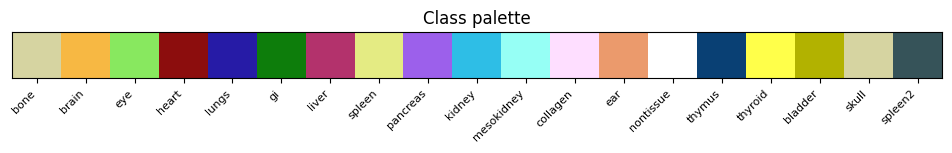

In [4]:
_cm = build_class_colormap(model.num_classes, idx2label, LABELS_VIZ, COLORS_VIZ)
_color_for_class_idx = _cm["color_for_idx"]    # callable(cls_idx) -> float RGB [0,1]
_color_for_class_name = _cm["color_for_name"]  # callable(name)    -> uint8 RGB tuple
CMAP_CLASS      = _cm["cmap"]
NORM_CLASS      = _cm["norm"]
IDX_TO_RGB_INT  = _cm["idx_to_rgb_int"]
_class_colors_float = _cm["colors_float"]

print("Colour map built.")
fig, ax = plt.subplots(figsize=(12, 0.6))
ax.imshow([_class_colors_float], aspect="auto")
ax.set_xticks(range(model.num_classes))
ax.set_xticklabels([idx2label.get(i, str(i)) for i in range(model.num_classes)], rotation=45, ha="right", fontsize=8)
ax.set_yticks([])
ax.set_title("Class palette")
plt.tight_layout()
plt.show()


---
## 5 · Diagnostic — open slide & pick tile

Opens `SLIDE_PATH` (controlled by `SLIDE_INDEX` in Parameters) and picks a representative tile according to `SAMPLE_MODE` (`random` / `centre` / `fixed`).

Shows a **thumbnail with the tile location** highlighted.  The batch in Cell 7 opens each slide independently — this cell is for visual checks only.

Slide : monkey_fetus_GS55_0070.ndpi  76800×49280 px at level 0
Diagnostic tile : (53931, 3224) size 256×256 px  (mode='random')


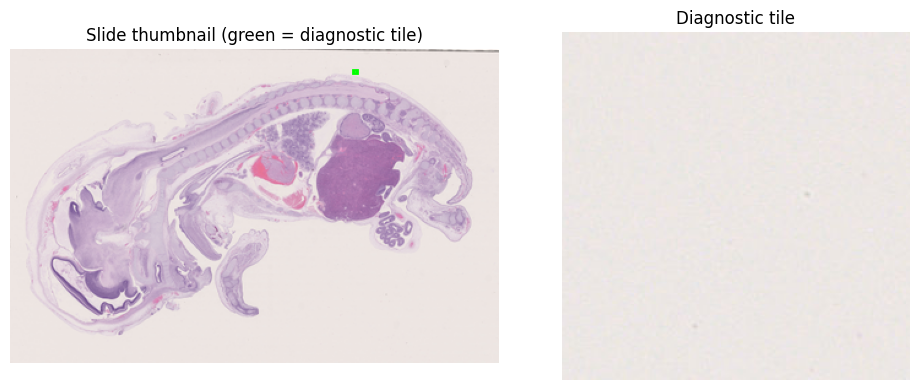

In [5]:
slide  = openslide.open_slide(str(SLIDE_PATH))
W_slide, H_slide = slide.level_dimensions[SLIDE_LEVEL]
print(f"Slide : {SLIDE_PATH.name}  {W_slide}×{H_slide} px at level {SLIDE_LEVEL}")

# ── Pick diagnostic tile ──────────────────────────────────────────────────────
sx, sy, rw, rh = pick_diagnostic_tile(
    W_slide, H_slide, TILE_SIZE,
    mode=SAMPLE_MODE, sample_x=SAMPLE_X, sample_y=SAMPLE_Y,
)
sample_rgb = np.asarray(slide.read_region(
    (int(sx * slide.level_downsamples[SLIDE_LEVEL]),
     int(sy * slide.level_downsamples[SLIDE_LEVEL])),
    SLIDE_LEVEL, (rw, rh)
).convert("RGB"), dtype=np.uint8)
print(f"Diagnostic tile : ({sx}, {sy}) size {rw}×{rh} px  (mode='{SAMPLE_MODE}')")

# ── Thumbnail with tile location ──────────────────────────────────────────────
thumb_w = 400
thumb_h = int(H_slide * thumb_w / W_slide)
thumb   = np.asarray(slide.get_thumbnail((thumb_w, thumb_h)).convert("RGB"))
sx_t = int(sx * thumb_w / W_slide)
sy_t = int(sy * thumb_h / H_slide)
rw_t = max(3, int(rw * thumb_w / W_slide))
rh_t = max(3, int(rh * thumb_h / H_slide))

fig, (ax_thumb, ax_tile) = plt.subplots(1, 2, figsize=(10, 4))
ax_thumb.imshow(thumb)
ax_thumb.add_patch(mpatches.Rectangle((sx_t, sy_t), rw_t, rh_t,
                                       linewidth=2, edgecolor="lime", facecolor="none"))
ax_thumb.set_title("Slide thumbnail (green = diagnostic tile)")
ax_thumb.axis("off")
ax_tile.imshow(sample_rgb)
ax_tile.set_title("Diagnostic tile")
ax_tile.axis("off")
plt.tight_layout()
plt.show()


---
## 6 · Diagnostic — single-tile inference

Runs the model on the one tile chosen in Cell 5 and shows an 8-panel figure:

| | |
|---|---|
| RGB | Probability map |
| Mean distance | Loose vs final peaks |
| Class argmax (FG only) | Polygon overlay |
| Per-class pixel distribution | Probability histogram |

Use this to check `PROB_THRESH`, peak count, and class colours before running the batch.

[diag] dist_map range : [0.0564, 19.1660]

 idx  name               mean_logit_raw   mean_logit_perm
  [ 0]  bone                          nan               nan
  [ 1]  brain                         nan               nan
  [ 2]  eye                           nan               nan
  [ 3]  heart                         nan               nan
  [ 4]  lungs                         nan               nan
  [ 5]  gi                            nan               nan
  [ 6]  liver                         nan               nan
  [ 7]  spleen                        nan               nan
  [ 8]  pancreas                      nan               nan
  [ 9]  kidney                        nan               nan
  [10]  mesokidney                    nan               nan
  [11]  collagen                      nan               nan
  [12]  ear                           nan               nan
  [13]  nontissue                     nan               nan
  [14]  thymus                        nan               nan

C:\Users\Andre\AppData\Local\Temp\ipykernel_23620\3028726958.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 3].legend(loc="upper right", fontsize=7);  axes[0, 3].set_title("Peaks");  axes[0, 3].axis("off")


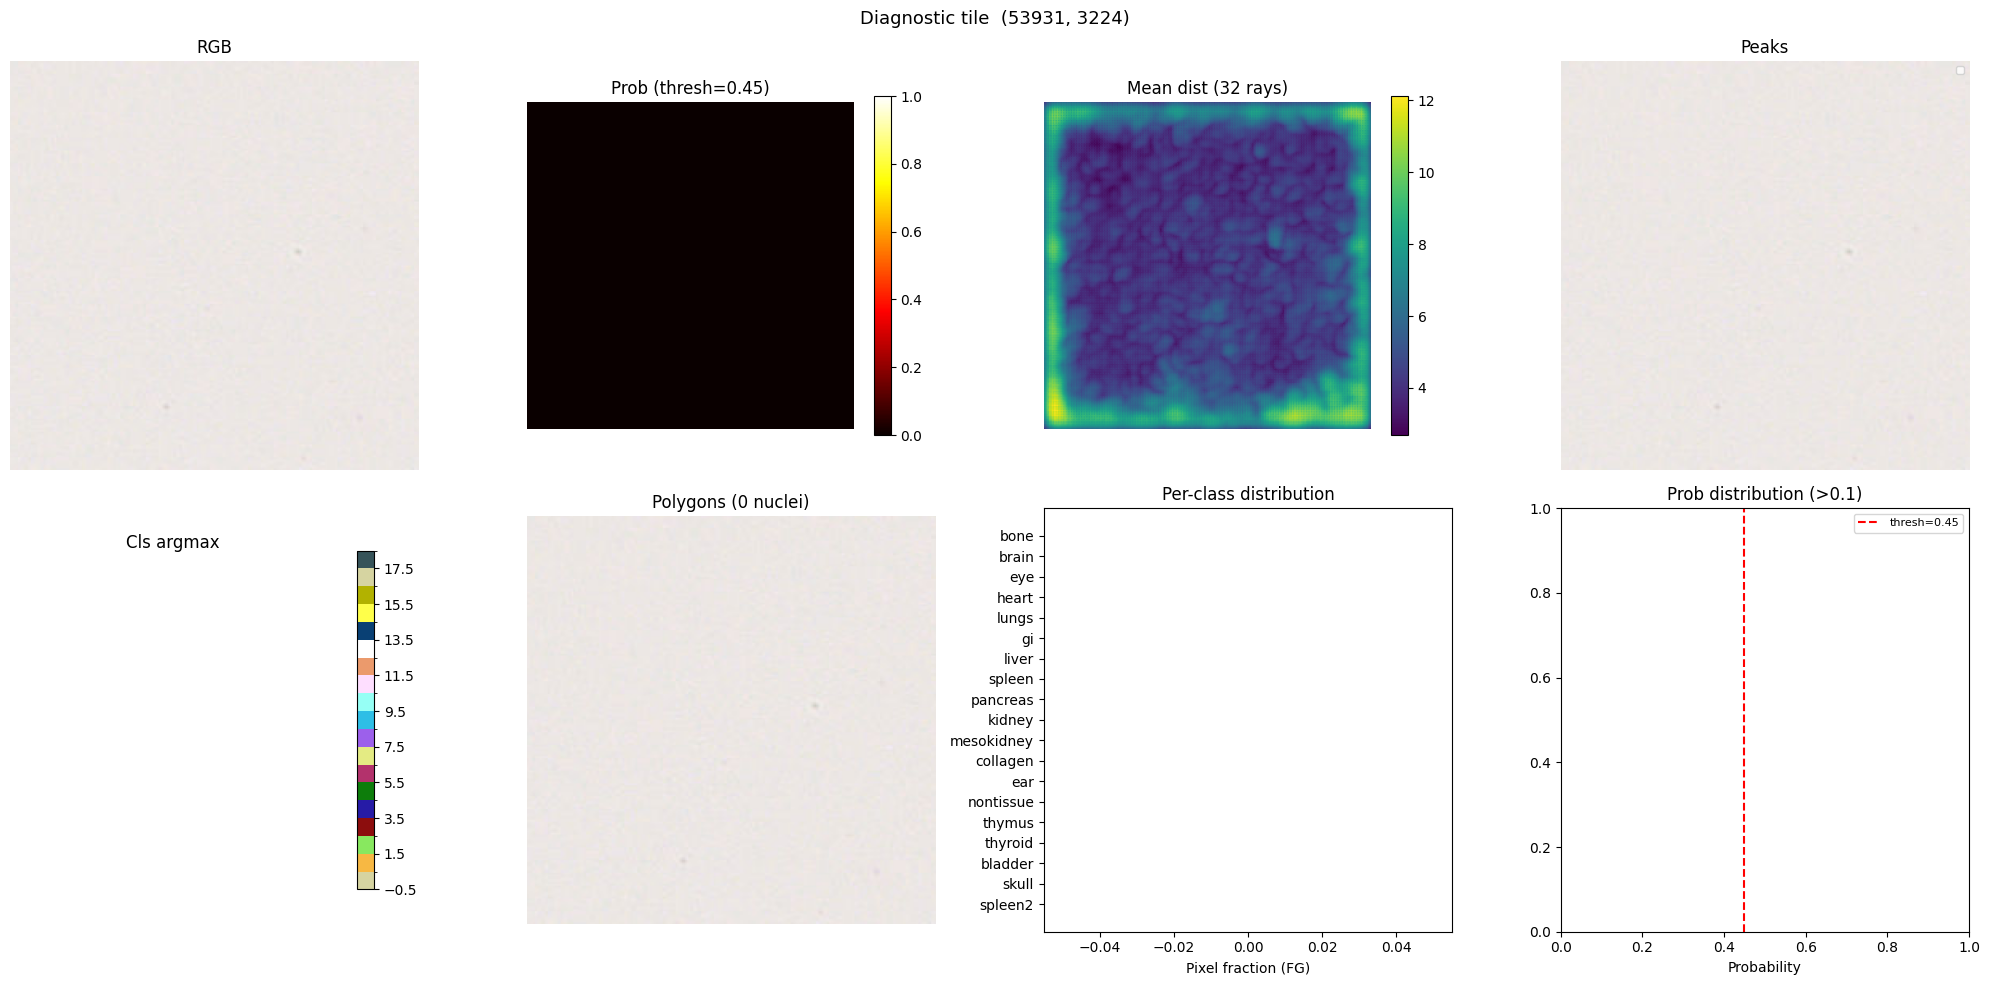

In [6]:
# ── 1. Run model on tile ──────────────────────────────────────────────────────
prob, dist_map, cls_log_raw = run_tile(model, sample_rgb, DEVICE)

# Apply permutation if needed
cls_log = cls_log_raw.copy()
if cls_perm is not None:
    cls_log = cls_log[cls_perm]

cls_argmax  = cls_log.argmax(axis=0)    # (H, W) display indices
mean_dist   = dist_map.mean(axis=0)     # (H, W)
_fg         = prob > 0.1

# ── 2. Classifier debug table ────────────────────────────────────────────────
print(f"[diag] dist_map range : [{dist_map.min():.4f}, {dist_map.max():.4f}]")
print(f"\n{'idx':>4}  {'name':16s}  {'mean_logit_raw':>15}  {'mean_logit_perm':>16}")
for i in range(model.num_classes):
    mr = float(cls_log_raw[i][_fg].mean()) if _fg.any() else float("nan")
    mp = float(cls_log[i][_fg].mean())     if _fg.any() else float("nan")
    print(f"  [{i:2d}]  {str(idx2label.get(i,'?')):16s}  {mr:15.4f}  {mp:16.4f}")

print("\nForeground class counts (permuted):")
for ni in range(model.num_classes):
    n = int((cls_argmax[_fg] == ni).sum())
    if n > 0:
        print(f"  [{ni:2d}]  {str(idx2label.get(ni,'?')):16s}  pixels={n:,}")

# ── 3. Peaks ─────────────────────────────────────────────────────────────────
_loose_peaks = local_peaks(prob, min_distance=int(DIAG_RAW_PEAK_NMS_DIST), thresh=float(DIAG_RAW_PEAK_THRESH))
peaks = local_peaks(prob, min_distance=int(NMS_DIST), thresh=float(PROB_THRESH))
_n0 = len(peaks)
if DIAG_PEAK_DEDUP_MIN_DIST_PX and len(peaks) > 1:
    _scores = prob[peaks[:, 0], peaks[:, 1]]
    _order  = np.argsort(-_scores)
    _keep   = []
    _md2    = float(DIAG_PEAK_DEDUP_MIN_DIST_PX) ** 2
    for _idx in _order:
        r, c = int(peaks[_idx, 0]), int(peaks[_idx, 1])
        if all((r - r2)**2 + (c - c2)**2 >= _md2 for r2, c2 in _keep):
            _keep.append((r, c))
    peaks = np.array(_keep, dtype=np.int64) if _keep else np.zeros((0, 2), dtype=np.int64)

_, coords_pk = dists_and_coords_from_peaks(
    dist_map, peaks, prob,
    refine_local_com=REFINE_PEAK_LOCAL_COM,
    refine_radius_px=int(REFINE_PEAK_RADIUS),
)
print(f"\n[diag] peaks: loose={len(_loose_peaks)}  after NMS={_n0}  after dedup={len(peaks)}")
if len(peaks) > 0:
    _md = mean_dist[peaks[:, 0], peaks[:, 1]]
    print(f"[diag] mean_dist at peaks: min={_md.min():.2f}  median={float(np.median(_md)):.2f}  max={_md.max():.2f}")

# ── 4. Build + dedup polygon features for overlay ────────────────────────────
_diag_feats = []
for k in range(coords_pk.shape[0]):
    cls_id, _ = vote_class(cls_log, coords_pk[k], sample_rgb.shape[:2])
    ring = polygon_ring_rowcol(coords_pk[k])
    r, c = int(peaks[k, 0]), int(peaks[k, 1])
    _diag_feats.append({
        "type": "Feature", "id": str(k),
        "geometry": {"type": "Polygon", "coordinates": [ring.tolist()]},
        "properties": {
            "classification": {"name": idx2label.get(cls_id, str(cls_id)), "index": int(cls_id)},
            "prob_peak": float(prob[r, c]),
        },
    })

_n_poly0 = len(_diag_feats)
if DIAG_TILE_DEDUP_CENTROID_PX:
    _diag_feats = dedupe_nucleus_features_by_centroid(_diag_feats, min_dist_px=float(DIAG_TILE_DEDUP_CENTROID_PX))
if DIAG_TILE_OVERLAP_DEDUP:
    try:
        _diag_feats = dedupe_nucleus_features_by_polygon_overlap(
            _diag_feats,
            min_overlap_ratio=float(DIAG_TILE_OVERLAP_RATIO),
            min_iou=float(DIAG_TILE_MIN_IOU) if DIAG_TILE_MIN_IOU else None,
            grid_cell_px=float(DEDUP_OVERLAP_GRID_PX),
        )
    except ImportError:
        print("(shapely not installed — overlap dedup skipped)")

print(f"[diag] polygons: {_n_poly0} → {len(_diag_feats)} after dedup")

# ── 5. 2×4 Figure ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(f"Diagnostic tile  ({sx}, {sy})", fontsize=13)

# [0,0] RGB
axes[0, 0].imshow(sample_rgb);  axes[0, 0].set_title("RGB");  axes[0, 0].axis("off")

# [0,1] Prob map
im1 = axes[0, 1].imshow(prob, cmap="hot", vmin=0, vmax=1)
axes[0, 1].set_title(f"Prob (thresh={PROB_THRESH})");  axes[0, 1].axis("off")
plt.colorbar(im1, ax=axes[0, 1], shrink=0.8)

# [0,2] Mean dist
im2 = axes[0, 2].imshow(mean_dist, cmap="viridis")
axes[0, 2].set_title(f"Mean dist ({model.n_rays} rays)");  axes[0, 2].axis("off")
plt.colorbar(im2, ax=axes[0, 2], shrink=0.8)

# [0,3] Loose vs final peaks
axes[0, 3].imshow(sample_rgb)
if len(_loose_peaks):
    axes[0, 3].scatter(_loose_peaks[:, 1], _loose_peaks[:, 0], c="red",  s=5, alpha=0.35, label=f"loose ({len(_loose_peaks)})")
if len(peaks):
    axes[0, 3].scatter(peaks[:, 1], peaks[:, 0], c="cyan", s=14, marker="x", linewidths=0.8, label=f"final ({len(peaks)})")
axes[0, 3].legend(loc="upper right", fontsize=7);  axes[0, 3].set_title("Peaks");  axes[0, 3].axis("off")

# [1,0] Cls argmax
fg_mask = prob > 0.1
cls_disp = np.where(fg_mask, cls_argmax, -1).astype(float)
cls_disp[cls_disp < 0] = np.nan
im3 = axes[1, 0].imshow(cls_disp, cmap=CMAP_CLASS, norm=NORM_CLASS)
_uq = np.unique(cls_argmax[fg_mask]) if fg_mask.any() else []
_cls_note = " (only " + idx2label.get(int(_uq[0]), str(_uq[0])) + ")" if len(_uq) == 1 else ""
axes[1, 0].set_title(f"Cls argmax{_cls_note}");  axes[1, 0].axis("off")
plt.colorbar(im3, ax=axes[1, 0], shrink=0.8)

# [1,1] Polygon overlay
axes[1, 1].imshow(sample_rgb)
for feat in _diag_feats:
    ring   = np.asarray(feat["geometry"]["coordinates"][0])
    cls_id = int(feat["properties"]["classification"]["index"])
    col    = _color_for_class_idx(cls_id)
    axes[1, 1].plot(ring[:, 0], ring[:, 1], linewidth=0.7, color=col)
axes[1, 1].set_title(f"Polygons ({len(_diag_feats)} nuclei)");  axes[1, 1].axis("off")

# [1,2] Per-class pixel bar
fg_cls = cls_argmax[fg_mask]
counts = np.bincount(fg_cls, minlength=model.num_classes)
fracs  = counts / (counts.sum() + 1e-9)
axes[1, 2].barh(
    [idx2label.get(i, str(i)) for i in range(model.num_classes)],
    fracs,
    color=[_color_for_class_idx(i) for i in range(model.num_classes)],
)
axes[1, 2].set_xlabel("Pixel fraction (FG)");  axes[1, 2].invert_yaxis()
axes[1, 2].set_title("Per-class distribution")

# [1,3] Prob histogram
_pb = prob[prob > 0.1].flatten()
if _pb.size:
    axes[1, 3].hist(_pb, bins=50, color="steelblue", edgecolor="black", alpha=0.85)
axes[1, 3].axvline(float(PROB_THRESH), color="red", linestyle="--", linewidth=1.5, label=f"thresh={PROB_THRESH}")
axes[1, 3].set_xlabel("Probability");  axes[1, 3].set_title("Prob distribution (>0.1)")
axes[1, 3].legend(fontsize=8)

plt.tight_layout();  plt.show()

---
## 7 · Batch inference — all slides in folder

Processes every file matching `WSI_GLOB` under `WSI_DIR` (alphabetically sorted).

**Per slide:**
1. Open slide → optional full-slide RAM load
2. Build tile grid (`TILE_SIZE`, `TILE_OVERLAP`)
3. GPU inference in batches of `BATCH_TILES` (fp16 if `USE_FP16`)
4. Centroid dedup → optional polygon-overlap dedup
5. Write `{stem}_classified.geojson` and `{stem}_summary.json`

**Tile I/O strategy:**
- `LOAD_TO_RAM = True` → slide loaded once into a numpy array; tiles sliced via `ThreadPoolExecutor(NUM_WORKERS)` — avoids worker processes duplicating the full array in memory
- `LOAD_TO_RAM = False` → tiles fetched on-demand via `DataLoader` with `NUM_WORKERS` parallel reader processes and `pin_memory=True`

> **Note:** `BATCH_TILES ≤ 128` for 256 px tiles — larger values overflow INT_MAX in PyTorch's bilinear upsample.

In [ ]:
# Guard: permutation must be set if required
if PERMUTE_LEGACY_TO_DISPLAY and cls_perm is None:
    raise RuntimeError("cls_perm is None — re-run Cell 3 before running inference.")

print(f"  cls_perm : {'ON (legacy → display)' if cls_perm is not None else 'OFF'}")

torch.backends.cudnn.benchmark = True

def _is_tissue_tile(tile_hwc):
    if not BG_FILTER_ENABLED:
        return True
    gray = tile_hwc.mean(axis=2)
    return float((gray < BG_THRESHOLD).mean()) >= MIN_TISSUE_FRAC

_fp16 = USE_FP16 and DEVICE.type == "cuda"
model.half() if _fp16 else model.float()
print(f"  model dtype : {'fp16' if _fp16 else 'fp32'}")

_base_post_kw = dict(
    nms_dist=NMS_DIST, prob_thresh=PROB_THRESH,
    refine_local_com=REFINE_PEAK_LOCAL_COM, refine_radius_px=REFINE_PEAK_RADIUS,
    cls_perm=cls_perm, vote_window_px=VOTE_WINDOW_PX, include_class_probs=INCLUDE_CLASS_PROBS,
)

all_wsi_files = sorted(WSI_DIR.glob(WSI_GLOB))
print(f"\nFound {len(all_wsi_files)} WSI files to process")
all_summaries = []

# ══════════════════════════════════════════════════════════════════════════════
for wsi_idx, SLIDE_PATH in enumerate(all_wsi_files):
    print(f"\n{'='*80}")
    print(f"Processing WSI {wsi_idx + 1}/{len(all_wsi_files)}: {SLIDE_PATH.name}")
    print(f"{'='*80}")

    _gj_suf  = ".geojson.gz" if GEOJSON_GZIP else ".geojson"
    path_cls = OUT_DIR / f"{SLIDE_PATH.stem}_classified{_gj_suf}"
    if path_cls.exists():
        print(f"  SKIP — output already exists: {path_cls.name}")
        continue

    t0 = time.perf_counter()

    try:
        slide = openslide.OpenSlide(str(SLIDE_PATH))
    except Exception as e:
        print(f"  ERROR opening slide: {e}"); continue

    W_slide, H_slide = slide.level_dimensions[SLIDE_LEVEL]
    print(f"  Dimensions (level {SLIDE_LEVEL}): {W_slide} × {H_slide}")

    _slide_ram = None
    if LOAD_TO_RAM:
        _mb = W_slide * H_slide * 3 / 1e6
        print(f"  Loading {W_slide}×{H_slide} px slide to RAM  (~{_mb:.0f} MB) …")
        _t = time.perf_counter()
        _slide_ram = np.asarray(
            slide.read_region((0, 0), SLIDE_LEVEL, (W_slide, H_slide)).convert("RGB"),
            dtype=np.uint8,
        )
        print(f"    Done in {time.perf_counter() - _t:.1f}s")

    _step       = max(1, TILE_SIZE - int(TILE_OVERLAP))
    tile_coords = build_tile_coords(W_slide, H_slide, TILE_SIZE, TILE_OVERLAP)
    _n_tiles_total = len(tile_coords)
    _n_tiles_skipped = 0
    print(f"  Tiles  : {len(tile_coords)}  (step={_step}, overlap={TILE_OVERLAP})")
    print(f"  Batch  : {BATCH_TILES}  |  NUM_WORKERS={NUM_WORKERS}")

    ALL_FEATURES: list[dict] = []
    _feat_id = [0]
    t_io = 0.0
    t_gpu = [0.0]

    _post_kw = dict(**_base_post_kw, valid_margin=VALID_MARGIN,
                    w_slide=W_slide, h_slide=H_slide, idx2label=idx2label)

    _desc = f"Infer {SLIDE_PATH.stem[:30]}"

    def _drain(fut):
        """Collect a completed postprocess future (blocks if not yet done)."""
        if fut is None:
            return
        feats = fut.result()
        for f in feats:
            f["id"] = str(_feat_id[0]); _feat_id[0] += 1
        ALL_FEATURES.extend(feats)

    # ── Inference loop — pipelined GPU fwd ↔ CPU post ────────────────────────
    # Correct order per iteration:
    #   1. tile extract  (fast, ~50 ms)
    #   2. GPU forward   (main thread, ~1.15 s)  ← CPU post of prev batch runs HERE
    #   3. _drain        (should be instant: CPU finished during step 2)
    #   4. submit CPU post for this batch         ← runs during next GPU forward
    if _slide_ram is None:
        tile_loader = make_wsi_tile_dataloader(
            str(SLIDE_PATH), SLIDE_LEVEL, tile_coords,
            batch_size=BATCH_TILES, num_workers=NUM_WORKERS,
            prefetch_factor=PREFETCH, pin_memory=(DEVICE.type == "cuda"),
            persistent_workers=True,
        )
        print("  Loader : DataLoader  |  Pipeline: CPU post overlaps GPU fwd")
        pbar    = tqdm(total=len(tile_coords), desc=_desc, unit="tile")
        _pending = None
        with concurrent.futures.ThreadPoolExecutor(max_workers=1) as _post_pool:
            for patches, idxs in tile_loader:
                meta = [tile_coords[i] for i in idxs]
                if BG_FILTER_ENABLED:
                    keep = [i for i, p in enumerate(patches) if _is_tissue_tile(p)]
                    _n_tiles_skipped += len(meta) - len(keep)
                    if not keep:
                        pbar.update(len(meta)); continue
                    patches = [patches[i] for i in keep]
                    meta    = [meta[i]    for i in keep]
                # ① GPU forward (CPU post of prev batch runs concurrently)
                _t = time.perf_counter()
                _results = forward_batch_with_perm(model, patches, DEVICE, fp16=_fp16, cls_perm=cls_perm)
                t_gpu[0] += time.perf_counter() - _t
                # ② drain prev CPU post (instant: ran during GPU fwd above)
                _drain(_pending)
                # ③ submit CPU post for this batch (runs during next GPU fwd)
                _pending = _post_pool.submit(postprocess_batch_v4, list(meta), _results, **_post_kw)
                pbar.update(len(meta))
                pbar.set_postfix(nuclei=_feat_id[0])
            _drain(_pending)
        pbar.close()
    else:
        _nw = max(1, int(NUM_WORKERS))
        print(f"  Loader : ThreadPoolExecutor({_nw})  |  Pipeline: CPU post overlaps GPU fwd")
        with concurrent.futures.ThreadPoolExecutor(max_workers=_nw) as pool, \
             concurrent.futures.ThreadPoolExecutor(max_workers=1) as _post_pool:
            pbar    = tqdm(total=len(tile_coords), desc=_desc, unit="tile")
            _pending = None
            for bs in range(0, len(tile_coords), BATCH_TILES):
                meta = tile_coords[bs: bs + BATCH_TILES]
                _t   = time.perf_counter()
                futs = [pool.submit(get_tile_from_ram, _slide_ram, x0, y0, tw, th)
                        for x0, y0, tw, th in meta]
                patches = [f.result() for f in futs]
                t_io += time.perf_counter() - _t
                if BG_FILTER_ENABLED:
                    keep = [i for i, p in enumerate(patches) if _is_tissue_tile(p)]
                    _n_tiles_skipped += len(meta) - len(keep)
                    if not keep:
                        pbar.update(len(meta)); continue
                    patches = [patches[i] for i in keep]
                    meta    = [meta[i]    for i in keep]
                # ① GPU forward (CPU post of prev batch runs concurrently)
                _t = time.perf_counter()
                _results = forward_batch_with_perm(model, patches, DEVICE, fp16=_fp16, cls_perm=cls_perm)
                t_gpu[0] += time.perf_counter() - _t
                # ② drain prev CPU post (instant: ran during GPU fwd above)
                _drain(_pending)
                # ③ submit CPU post for this batch (runs during next GPU fwd)
                _pending = _post_pool.submit(postprocess_batch_v4, list(meta), _results, **_post_kw)
                pbar.update(len(meta))
                pbar.set_postfix(nuclei=_feat_id[0])
            _drain(_pending)
            pbar.close()

    print(f"  Timers: tile I/O {t_io:.1f}s  |  GPU forward {t_gpu[0]:.1f}s")
    if BG_FILTER_ENABLED:
        print(f"  BG filter: {_n_tiles_skipped:,} / {_n_tiles_total:,} skipped ({100*_n_tiles_skipped/max(_n_tiles_total,1):.1f}%)")
    _n_raw = len(ALL_FEATURES)

    # ── Deduplication ─────────────────────────────────────────────────────────
    print(f"  Raw detections : {_n_raw:,}")
    _td = time.perf_counter()
    ALL_FEATURES = dedupe_nucleus_features_by_centroid(ALL_FEATURES, min_dist_px=float(DEDUP_MIN_DIST_PX))
    for i, f in enumerate(ALL_FEATURES): f["id"] = str(i)
    print(f"  After centroid dedup : {len(ALL_FEATURES):,}  ({time.perf_counter()-_td:.1f}s)")

    if DEDUP_USE_POLYGON_OVERLAP:
        _to = time.perf_counter()
        ALL_FEATURES = dedupe_nucleus_features_by_polygon_overlap(
            ALL_FEATURES,
            min_overlap_ratio=float(DEDUP_OVERLAP_RATIO),
            min_iou=float(DEDUP_MIN_IOU) if DEDUP_MIN_IOU else None,
            grid_cell_px=float(DEDUP_OVERLAP_GRID_PX),
        )
        for i, f in enumerate(ALL_FEATURES): f["id"] = str(i)
        print(f"  After overlap dedup  : {len(ALL_FEATURES):,}  ({time.perf_counter()-_to:.1f}s)")

    _t_infer_end  = time.perf_counter()
    ELAPSED_INFER = _t_infer_end - t0
    print(f"  Total nuclei : {len(ALL_FEATURES):,}")
    print(f"  Inference+dedup: {ELAPSED_INFER:.1f}s  ({ELAPSED_INFER/60:.1f} min)")

    # ── Build classified features ─────────────────────────────────────────────
    cls_feats = []
    for feat in ALL_FEATURES:
        cls_id  = int(feat["properties"]["classification"]["index"])
        name    = idx2label.get(cls_id, str(cls_id))
        r, g, b = _color_for_class_name(name)
        f = feat_classified(feat)
        f["properties"]["classification"]["colorRGB"] = (r << 16) | (g << 8) | b
        cls_feats.append(f)

    # ── Write GeoJSON ──────────────────────────────────────────────────────────
    _gj_t = time.perf_counter()
    write_geojson_feature_collection_v4(
        path_cls, cls_feats,
        coord_decimals=GEOJSON_COORD_DECIMALS,
        gzip_compress=GEOJSON_GZIP,
        use_orjson=USE_ORJSON,
    )
    _gj_write_s = time.perf_counter() - _gj_t
    print(f"  GeoJSON write : {_gj_write_s:.2f}s  →  {path_cls}")

    class_counts = {}
    for feat in ALL_FEATURES:
        nm = feat["properties"]["classification"]["name"]
        class_counts[nm] = class_counts.get(nm, 0) + 1

    _t_all_end    = time.perf_counter()
    ELAPSED_TOTAL = _t_all_end - t0
    ELAPSED_EXPORT = _t_all_end - _t_infer_end

    summary = {
        "wsi_dir": str(WSI_DIR), "wsi_glob": WSI_GLOB,
        "slide_index": wsi_idx, "slide": str(SLIDE_PATH), "slide_name": SLIDE_PATH.name,
        "weights": str(WEIGHTS_PATH), "slide_level": SLIDE_LEVEL,
        "tile_size": TILE_SIZE, "tile_overlap": TILE_OVERLAP, "tile_step": _step,
        "valid_margin": VALID_MARGIN, "prob_thresh": PROB_THRESH, "nms_dist": NMS_DIST,
        "permute_legacy": PERMUTE_LEGACY_TO_DISPLAY,
        "dedup_centroid_px": DEDUP_MIN_DIST_PX, "dedup_overlap": DEDUP_USE_POLYGON_OVERLAP,
        "total_nuclei": len(ALL_FEATURES),
        "elapsed_infer_dedup_s": round(ELAPSED_INFER, 2),
        "elapsed_export_s":      round(ELAPSED_EXPORT, 2),
        "elapsed_total_s":       round(ELAPSED_TOTAL, 2),
        "class_counts": class_counts,
        "geojson_classified": str(path_cls),
    }
    summary_path = OUT_DIR / f"{SLIDE_PATH.stem}_summary.json"
    summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
    all_summaries.append(summary)

    print(f"  Summary → {summary_path}")
    print(f"  TOTAL: {ELAPSED_TOTAL:.1f}s  ({ELAPSED_TOTAL/60:.1f} min)")
    print(f"  Nuclei per class:")
    for nm, cnt in sorted(class_counts.items(), key=lambda x: -x[1]):
        print(f"    {nm:16s} {cnt:,}")

    slide.close()
    del _slide_ram
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

model.float()


---
## 7b · Combined summary

Aggregates nucleus counts and timings across all processed slides and writes `all_slides_summary.json` to `OUT_DIR`.

`ALL_FEATURES`, `class_counts`, and `SLIDE_PATH` reflect the **last** slide in the batch — Cell 8 uses them for its chart.

In [ ]:
# ── Combined summary across all slides ──────────────────────────────────────
───────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*80}")
print(f"ALL WSI PROCESSING COMPLETE")
print(f"{'='*80}")

# Aggregate statistics
total_nuclei_all = sum(s["total_nuclei"] for s in all_summaries)
total_time_all = sum(s["elapsed_total_s"] for s in all_summaries)

combined_class_counts = {}
for s in all_summaries:
    for cls_name, cnt in s["class_counts"].items():
        combined_class_counts[cls_name] = combined_class_counts.get(cls_name, 0) + cnt

combined_summary = {
    "total_slides_processed": len(all_summaries),
    "total_nuclei_all_slides": total_nuclei_all,
    "total_time_all_slides_s": round(total_time_all, 2),
    "total_time_all_slides_min": round(total_time_all / 60, 2),
    "avg_time_per_slide_s": round(total_time_all / len(all_summaries), 2) if all_summaries else 0,
    "combined_class_counts": combined_class_counts,
    "individual_summaries": all_summaries,
}

combined_summary_path = OUT_DIR / "all_slides_summary.json"
combined_summary_path.write_text(json.dumps(combined_summary, indent=2), encoding="utf-8")

print(f"\nProcessed {len(all_summaries)} slides")
print(f"Total nuclei across all slides: {total_nuclei_all:,}")
print(f"Total processing time: {total_time_all:.1f}s ({total_time_all/60:.1f} min)")
print(f"\nCombined class counts:")
for nm, cnt in sorted(combined_class_counts.items(), key=lambda x: -x[1]):
    print(f"  {nm:16s} {cnt:,}")
print(f"\nCombined summary saved to: {combined_summary_path}")

---
## 8 · Results chart (last slide)

Bar chart of nucleus counts per tissue class for the last slide processed in Cell 7.  Saved as `{stem}_class_counts.png` in `OUT_DIR`.

For per-slide stats across the full batch, open `all_slides_summary.json`.

In [ ]:
# Bar chart of per-class nucleus counts
sorted_classes = sorted(class_counts.items(), key=lambda x: -x[1])
names = [x[0] for x in sorted_classes]
cnts  = [x[1] for x in sorted_classes]
cols  = [np.array(_color_for_class_name(n)) / 255.0 for n in names]

fig, ax = plt.subplots(figsize=(10, max(4, len(names) * 0.45)))
ax.barh(names, cnts, color=cols)
ax.set_xlabel("Nucleus count")
ax.invert_yaxis()
ax.set_title(f"{SLIDE_PATH.name}  —  {len(ALL_FEATURES):,} nuclei total")
for i, v in enumerate(cnts):
    ax.text(v * 1.005, i, f"{v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f"{SLIDE_PATH.stem}_class_counts.png", dpi=150)
plt.show()